# 17. Capstone: An Interpretable Decision Pipeline

This capstone pulls the course together. We will build an end-to-end interpretable decision pipeline for a high-stakes working-capital approval problem.

The goal is to train a model and create a decision system that can be explained, audited, challenged, revised, and communicated.

The pipeline will answer six practical questions:

1. What decision is the model supporting?
2. Which model should we select, and why?
3. What threshold should be used for the decision policy?
4. What global and local explanations support the decision?
5. Are the explanations and decisions stable enough to use?
6. What governance artifacts should accompany deployment?

## Mathematical Core

An interpretable decision pipeline balances predictive performance, explanation quality, and operational guardrails. A compact objective is

$$
\min_f \; \hat R(f) + \lambda_1 C_{\mathrm{complexity}}(f) + \lambda_2 C_{\mathrm{instability}}(f),
$$

where

$$
\hat R(f) = \frac{1}{n}\sum_{i=1}^{n} \ell(y_i, f(x_i)).
$$

For explanations $E(x; f)$, stability can be checked across resamples or retrains,

$$
S_E = \mathbb{E}\left[\|E(x; f_b) - E(x; f_{b'})\|\right].
$$

The capstone is therefore a modeling exercise and a decision-system exercise where accuracy, interpretability, and governance all enter the final recommendation.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Build a transparent model baseline and compare it with a stronger candidate model.
2. Select a model using performance, calibration, interpretability, and governance criteria.
3. Choose a threshold using a simple decision-utility calculation.
4. Produce global explanations, local explanations, and explanation-stability diagnostics.
5. Audit subgroup decision behavior and recourse implications.
6. Package the final evidence into a deployment review record.

## 1. Capstone Review Standard

A model is not deployment-ready just because it has a good validation metric. In this capstone, a candidate model must pass a broader review.

| Review dimension | Question | Evidence we will produce |
|---|---|---|
| Predictive performance | Does the model rank repayment risk well? | ROC AUC, average precision, Brier score |
| Decision value | Does the threshold improve expected utility? | Utility curve over thresholds |
| Interpretability | Can the model's main drivers be explained? | Coefficients and permutation importance |
| Local review | Can a single decision be explained responsibly? | Focal case score, threshold gap, local contributions |
| Stability | Do explanations change materially across resamples? | Rank stability and top-feature overlap |
| Fairness and governance | Do subgroup metrics or recourse burden trigger review? | Approval, TPR, FPR, and burden metrics |
| Communication | Can evidence be summarized for stakeholders? | Deployment record and communication packet |

This is the full pipeline view of interpretable machine learning.

## 2. References Behind the Pipeline

Several ideas from the course come together here. Miller (2019) argues that explanations are social and contextual. Lipton (2018) warns that interpretability is often underspecified, so we must state the purpose of interpretation. Ribeiro, Singh, and Guestrin (2016) motivate local explanations for individual decisions. Mitchell et al. (2019) motivate model-reporting artifacts such as model cards. Hardt, Price, and Srebro (2016) give a useful subgroup fairness diagnostic through equality of opportunity. Janzing, Minorics, and Bloebaum (2019) remind us that feature relevance needs causal evidence before becoming causal relevance.

The capstone does not treat these as separate topics. It treats them as parts of one decision workflow.

In [1]:
# Section focus: 2. References Behind the Pipeline.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import hashlib
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 917
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 160)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))

In [2]:
# Section focus: 2. References Behind the Pipeline.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='900px'):
    """Display table for the 17. Capstone: An Interpretable Decision Pipeline notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top'), ('line-height', '1.3')]},
        {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', max_width)]},
    ])
    display(styler)


def safe_divide(numerator, denominator):
    """Carry out the safe divide step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
    
    Parameters
    ----------
    numerator : object
        The numerator setting that controls the safe divide calculation in this notebook.
    denominator : object
        The denominator setting that controls the safe divide calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the safe divide calculation and reused by later cells.
    """
    return np.nan if denominator == 0 else numerator / denominator


def short_hash(obj):
    """Carry out the short hash step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
    
    Parameters
    ----------
    obj : object
        The obj setting that controls the short hash calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the short hash calculation and reused by later cells.
    """
    payload = json.dumps(obj, sort_keys=True, default=str).encode('utf-8')
    return hashlib.sha256(payload).hexdigest()[:12]

The metric result should be read as an operating tradeoff. In References Behind the Pipeline, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The useful reading ties the number to the decision it could change.


## 3. Decision Case: Working-Capital Approval

A finance team wants to approve working-capital offers to small businesses. The model estimates repayment probability. The decision policy approves applications if the score is above a threshold.

The business benefit and cost are simplified:

- approving a business that repays creates benefit;
- approving a business that does not repay creates loss;
- denied applications receive no immediate loan profit or loss;
- some denied but qualified applications may create opportunity cost and fairness concerns.

This is a deliberately simplified decision case. The point is to practice the interpretable pipeline, not to model a full lending balance sheet.

### Decision Card

| Item | Specification |
|---|---|
| Decision | Approve, deny, or route a working-capital application to review |
| Model target | Successful repayment |
| Score | Estimated repayment probability |
| Policy threshold | Chosen by expected utility on evaluation data |
| Primary metric | ROC AUC and repayment rate among approved applications |
| Explanation requirement | Global drivers, local case explanation, stability diagnostics |
| Governance requirement | Subgroup metrics, recourse burden, model card fragment |
| Communication requirement | Executive, validator, analyst, and applicant-facing summaries |

In [3]:
# Section focus: Decision Card.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_working_capital_data(n=8500, seed=RANDOM_SEED):
    """Construct the working capital data helper used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    underserved_access_group = rng.binomial(1, 0.35, n)
    market_volatility = rng.normal(0.15 * underserved_access_group, 1, n)
    business_age = rng.normal(-0.20 * underserved_access_group, 1, n)
    operating_strength = rng.normal(-0.10 * underserved_access_group, 1, n)
    seasonality_risk = rng.normal(0, 1, n)

    revenue = (
        0.72 * operating_strength
        + 0.35 * business_age
        - 0.25 * market_volatility
        - 0.28 * underserved_access_group
        + rng.normal(0, 0.75, n)
    )
    cash_buffer = (
        0.70 * operating_strength
        - 0.30 * market_volatility
        - 0.20 * underserved_access_group
        + rng.normal(0, 0.78, n)
    )
    credit_history = (
        0.58 * operating_strength
        + 0.23 * business_age
        - 0.50 * underserved_access_group
        + rng.normal(0, 0.88, n)
    )
    digital_records = (
        0.48 * operating_strength
        + 0.22 * business_age
        - 0.42 * underserved_access_group
        + rng.normal(0, 0.90, n)
    )
    collateral = (
        0.42 * revenue
        + 0.25 * business_age
        - 0.38 * underserved_access_group
        + rng.normal(0, 0.92, n)
    )
    relationship_length = (
        0.50 * business_age
        + 0.16 * operating_strength
        - 0.15 * underserved_access_group
        + rng.normal(0, 0.82, n)
    )

    repayment_logit = (
        -0.05
        + 0.82 * operating_strength
        + 0.45 * cash_buffer
        + 0.35 * revenue
        + 0.22 * relationship_length
        - 0.48 * market_volatility
        + 0.12 * digital_records
        + 0.18 * np.maximum(cash_buffer, 0) * np.maximum(revenue, 0)
        - 0.15 * (market_volatility > 1.10) * underserved_access_group
        + 0.08 * seasonality_risk
    )
    repay_probability = sigmoid(repayment_logit)
    repays = rng.binomial(1, repay_probability)

    df = pd.DataFrame({
        'underserved_access_group': underserved_access_group,
        'market_volatility': market_volatility,
        'business_age': business_age,
        'operating_strength_latent': operating_strength,
        'revenue': revenue,
        'cash_buffer': cash_buffer,
        'credit_history': credit_history,
        'digital_records': digital_records,
        'collateral': collateral,
        'relationship_length': relationship_length,
        'seasonality_risk': seasonality_risk,
        'repays': repays,
        'repay_probability_true': repay_probability,
    })
    df['access_group'] = np.where(
        df['underserved_access_group'] == 1,
        'Underserved access group',
        'Established access group',
    )
    return df

applications = make_working_capital_data()

preview_columns = [
    'access_group',
    'revenue',
    'cash_buffer',
    'credit_history',
    'digital_records',
    'collateral',
    'relationship_length',
    'market_volatility',
    'business_age',
    'seasonality_risk',
    'repays',
]

display_table(applications[preview_columns].head(), precision=3, max_width='1000px')

,access_group,revenue,cash_buffer,credit_history,digital_records,collateral,relationship_length,market_volatility,business_age,seasonality_risk,repays
0,Established access group,-0.914,-0.161,-0.409,-0.668,-0.180,0.113,1.917,-0.789,0.428,0
1,Established access group,-0.230,-0.861,-0.284,-0.175,0.923,-0.761,-0.237,-0.372,-1.111,0
2,Established access group,0.384,-2.092,0.440,1.014,0.344,0.749,0.635,-0.374,-0.791,0
3,Established access group,0.964,-0.256,1.061,-0.009,0.760,0.672,0.390,-0.026,-2.434,0
4,Established access group,-0.836,-1.434,-0.733,-0.035,-0.376,-1.623,-1.224,-0.227,0.222,0


These numbers translate model behavior into decision consequences. For Decision Card, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


In [4]:
population_summary = (
    applications
    .groupby('access_group')
    .agg(
        applications=('repays', 'size'),
        repayment_rate=('repays', 'mean'),
        mean_revenue=('revenue', 'mean'),
        mean_cash_buffer=('cash_buffer', 'mean'),
        mean_credit_history=('credit_history', 'mean'),
        mean_market_volatility=('market_volatility', 'mean'),
    )
    .reset_index()
)

display_table(population_summary, precision=3, max_width='860px')

,access_group,applications,repayment_rate,mean_revenue,mean_cash_buffer,mean_credit_history,mean_market_volatility
0,Established access group,5516,0.492,-0.015,-0.014,0.013,0.016
1,Underserved access group,2984,0.395,-0.437,-0.331,-0.610,0.174


The groups differ in measured covariates and repayment rates. This does not decide fairness by itself, but it means deployment must include subgroup monitoring and careful communication.

This is the transition from scorekeeping to a rule someone can use. The useful reading is which metric would change the action in Decision Card. Metric conflict should lead to a cost discussion, not a popularity contest among scores.


## 4. Candidate Models

We compare two candidate models:

1. **Standardized logistic regression**, a transparent model with direct coefficient-based explanations.
2. **Random forest**, a flexible model that can capture nonlinearities and interactions but is less transparent.

The sensitive group indicator is excluded from model fitting and used only for audit reporting.

In [5]:
# Section focus: 4. Candidate Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

model_features = [
    'revenue',
    'cash_buffer',
    'credit_history',
    'digital_records',
    'collateral',
    'relationship_length',
    'market_volatility',
    'business_age',
    'seasonality_risk',
]

train_df, test_df = train_test_split(
    applications,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=applications['repays'],
)

candidate_models = {
    'Logistic regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'Random forest': RandomForestClassifier(
        n_estimators=260,
        min_samples_leaf=25,
        max_features='sqrt',
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

model_results = []
for model_name, candidate in candidate_models.items():
    candidate.fit(train_df[model_features], train_df['repays'])
    scores = candidate.predict_proba(test_df[model_features])[:, 1]
    model_results.append({
        'model': model_name,
        'roc_auc': roc_auc_score(test_df['repays'], scores),
        'average_precision': average_precision_score(test_df['repays'], scores),
        'brier_score': brier_score_loss(test_df['repays'], scores),
    })

model_comparison = pd.DataFrame(model_results).sort_values('roc_auc', ascending=False)
display_table(model_comparison, precision=3, max_width='760px')

,model,roc_auc,average_precision,brier_score
0,Logistic regression,0.836,0.816,0.164
1,Random forest,0.829,0.802,0.168


The transparent model is competitive and slightly stronger in this simulated evaluation. That matters. When a transparent model performs as well as or better than a less transparent model, interpretability is not a concession. It is the simpler and stronger deployment choice.

This result is an interpretation diagnostic. For Candidate Models, look at whether the explanation is stable, plausible, and useful for stakeholder review. The report should make clear when the explanation depends on the sample, baseline, or local neighborhood.


## 5. Model Selection Decision

We will select the logistic regression model because it has strong performance, stable explanations, straightforward local decomposition, and simpler governance. The random forest remains a challenger model for future monitoring or stress testing.

In [6]:
selected_model_name = 'Logistic regression'
selected_model = candidate_models[selected_model_name]

test_df = test_df.copy()
test_df['score'] = selected_model.predict_proba(test_df[model_features])[:, 1]

selected_metrics = pd.DataFrame({
    'metric': ['ROC AUC', 'Average precision', 'Brier score', 'Evaluation repayment rate'],
    'value': [
        roc_auc_score(test_df['repays'], test_df['score']),
        average_precision_score(test_df['repays'], test_df['score']),
        brier_score_loss(test_df['repays'], test_df['score']),
        test_df['repays'].mean(),
    ],
})

display_table(selected_metrics, precision=3, max_width='620px')

,metric,value
0,ROC AUC,0.836
1,Average precision,0.816
2,Brier score,0.164
3,Evaluation repayment rate,0.458


This result is an interpretation diagnostic. For Model Selection Decision, look at whether the explanation is stable, plausible, and useful for stakeholder review. The report should use fragile explanations carefully and show the reader where they move.


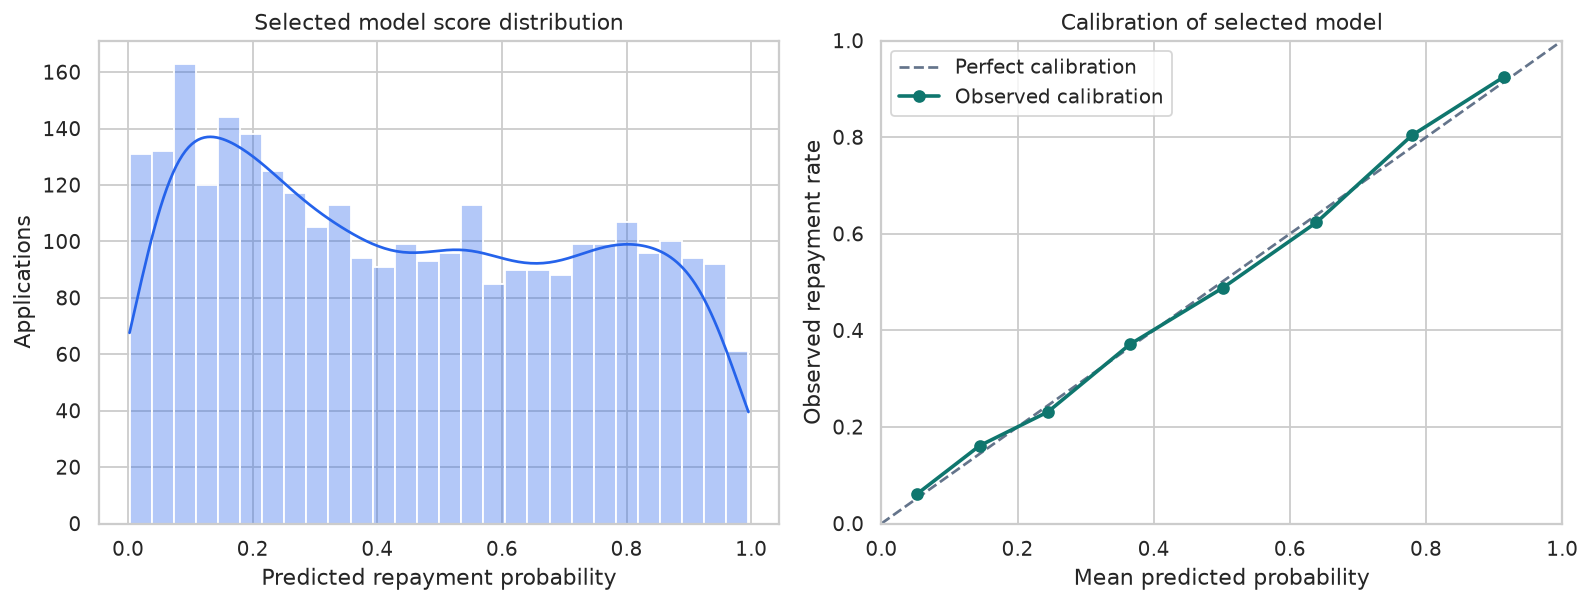

In [7]:
prob_true, prob_pred = calibration_curve(test_df['repays'], test_df['score'], n_bins=8, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

sns.histplot(test_df['score'], bins=28, kde=True, color='#2563eb', alpha=0.35, ax=axes[0])
axes[0].set_title('Selected model score distribution')
axes[0].set_xlabel('Predicted repayment probability')
axes[0].set_ylabel('Applications')

axes[1].plot([0, 1], [0, 1], color='#64748b', linestyle='--', label='Perfect calibration')
axes[1].plot(prob_pred, prob_true, marker='o', color='#0f766e', linewidth=2, label='Observed calibration')
axes[1].set_title('Calibration of selected model')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Observed repayment rate')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

Calibration is good enough for stakeholder communication in this simulated case, but we would still describe the score as an estimate, not as certainty.

The metric result should be read as an operating tradeoff. In Model Selection Decision, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. Performance matters when it changes how the system will be used.


## 6. Threshold Selection by Decision Utility

A model score becomes a decision only after a threshold is chosen. Let $D_i(t)$ denote approval at threshold $t$:

$$
D_i(t) = \mathbf{1}\{S_i \ge t\}.
$$

Use a simple utility model:

$$
U_i(t) = D_i(t) \{bY_i - c(1-Y_i)\},
$$

where $b$ is the benefit of approving a repaying applicant and $c$ is the loss from approving a non-repaying applicant. We set $b=1.0$ and $c=1.7$ for this exercise.

In [8]:
benefit_if_repaid = 1.0
loss_if_default = 1.7
threshold_grid = np.linspace(0.20, 0.80, 61)

utility_rows = []
for candidate_threshold in threshold_grid:
    approved = (test_df['score'] >= candidate_threshold).astype(int)
    utility = approved * (benefit_if_repaid * test_df['repays'] - loss_if_default * (1 - test_df['repays']))
    utility_rows.append({
        'threshold': candidate_threshold,
        'approval_rate': approved.mean(),
        'mean_utility_per_application': utility.mean(),
        'repayment_rate_among_approved': test_df.loc[approved == 1, 'repays'].mean(),
    })

utility_table = pd.DataFrame(utility_rows)
best_idx = utility_table['mean_utility_per_application'].idxmax()
selected_threshold = float(utility_table.loc[best_idx, 'threshold'])

display_table(utility_table.loc[[best_idx]].reset_index(drop=True), precision=3, max_width='760px')

,threshold,approval_rate,mean_utility_per_application,repayment_rate_among_approved
0,0.700,0.262,0.161,0.858


The metric result should be read as an operating tradeoff. In Threshold Selection by Decision Utility, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. Use the score to make the operating choice explicit.


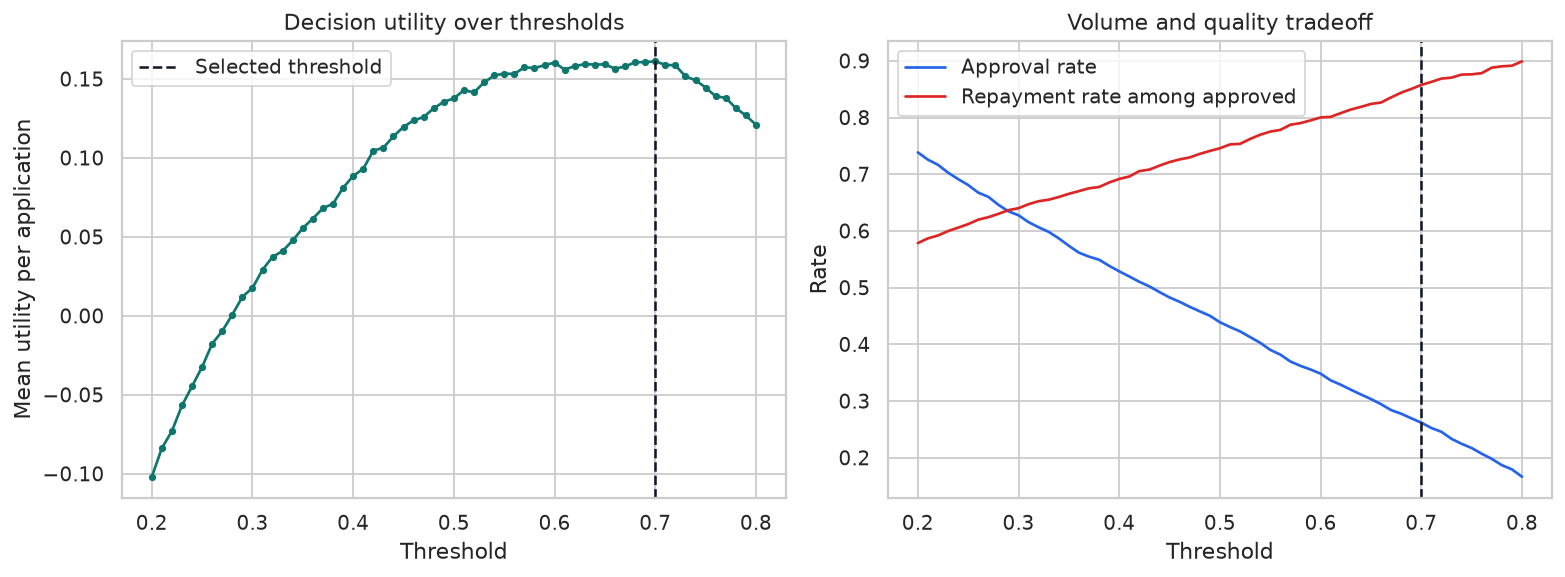

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))

axes[0].plot(utility_table['threshold'], utility_table['mean_utility_per_application'], color='#0f766e', marker='o', markersize=3)
axes[0].axvline(selected_threshold, color='#111827', linestyle='--', linewidth=1.4, label='Selected threshold')
axes[0].set_title('Decision utility over thresholds')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Mean utility per application')
axes[0].legend()

axes[1].plot(utility_table['threshold'], utility_table['approval_rate'], color='#2563eb', label='Approval rate')
axes[1].plot(utility_table['threshold'], utility_table['repayment_rate_among_approved'], color='#dc2626', label='Repayment rate among approved')
axes[1].axvline(selected_threshold, color='#111827', linestyle='--', linewidth=1.4)
axes[1].set_title('Volume and quality tradeoff')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

These numbers translate model behavior into decision consequences. For Threshold Selection by Decision Utility, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


In [10]:
test_df['approved'] = (test_df['score'] >= selected_threshold).astype(int)
test_df['decision'] = np.where(test_df['approved'] == 1, 'Approve', 'Deny or route to review')

decision_summary = pd.DataFrame({
    'quantity': ['Selected threshold', 'Approval rate', 'Repayment rate among approved', 'Mean utility per application'],
    'value': [
        selected_threshold,
        test_df['approved'].mean(),
        test_df.loc[test_df['approved'] == 1, 'repays'].mean(),
        utility_table.loc[best_idx, 'mean_utility_per_application'],
    ],
})

display_table(decision_summary, precision=3, max_width='650px')

,quantity,value
0,Selected threshold,0.700
1,Approval rate,0.262
2,Repayment rate among approved,0.858
3,Mean utility per application,0.161


This is a decision-science step. The model does not decide the threshold. The organization chooses a threshold by balancing expected benefit, risk, volume, fairness, and operational capacity.

The metric result should be read as an operating tradeoff. In Threshold Selection by Decision Utility, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The next step is to connect the metric with cost, risk, threshold choice, or the stakeholder decision.


## 7. Global Explanation

For the selected logistic regression model, standardized coefficients are a direct global explanation of the score. We also compute permutation importance on evaluation data to show how much predictive performance depends on each feature.

In [11]:
scaler = selected_model.named_steps['standardscaler']
logit_model = selected_model.named_steps['logisticregression']
coefs = pd.Series(logit_model.coef_[0], index=model_features).sort_values(ascending=False)

perm = permutation_importance(
    selected_model,
    test_df[model_features],
    test_df['repays'],
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)
raw_perm_importance = pd.Series(perm.importances_mean, index=model_features)
perm_importance = raw_perm_importance.clip(lower=0).sort_values(ascending=False)

global_explanation = pd.DataFrame({
    'feature': model_features,
    'standardized_coefficient': pd.Series(logit_model.coef_[0], index=model_features).values,
    'permutation_auc_drop': perm_importance.reindex(model_features).values,
}).sort_values('permutation_auc_drop', ascending=False)

display_table(global_explanation, precision=3, max_width='800px')


,feature,standardized_coefficient,permutation_auc_drop
1,cash_buffer,0.795,0.085
0,revenue,0.745,0.079
6,market_volatility,-0.333,0.016
5,relationship_length,0.242,0.011
2,credit_history,0.215,0.007
7,business_age,-0.233,0.006
3,digital_records,0.219,0.006
4,collateral,-0.004,0.000
8,seasonality_risk,0.045,0.000


For Global Explanation, the explanation earns trust through stability and reviewability, not through a polished chart alone.


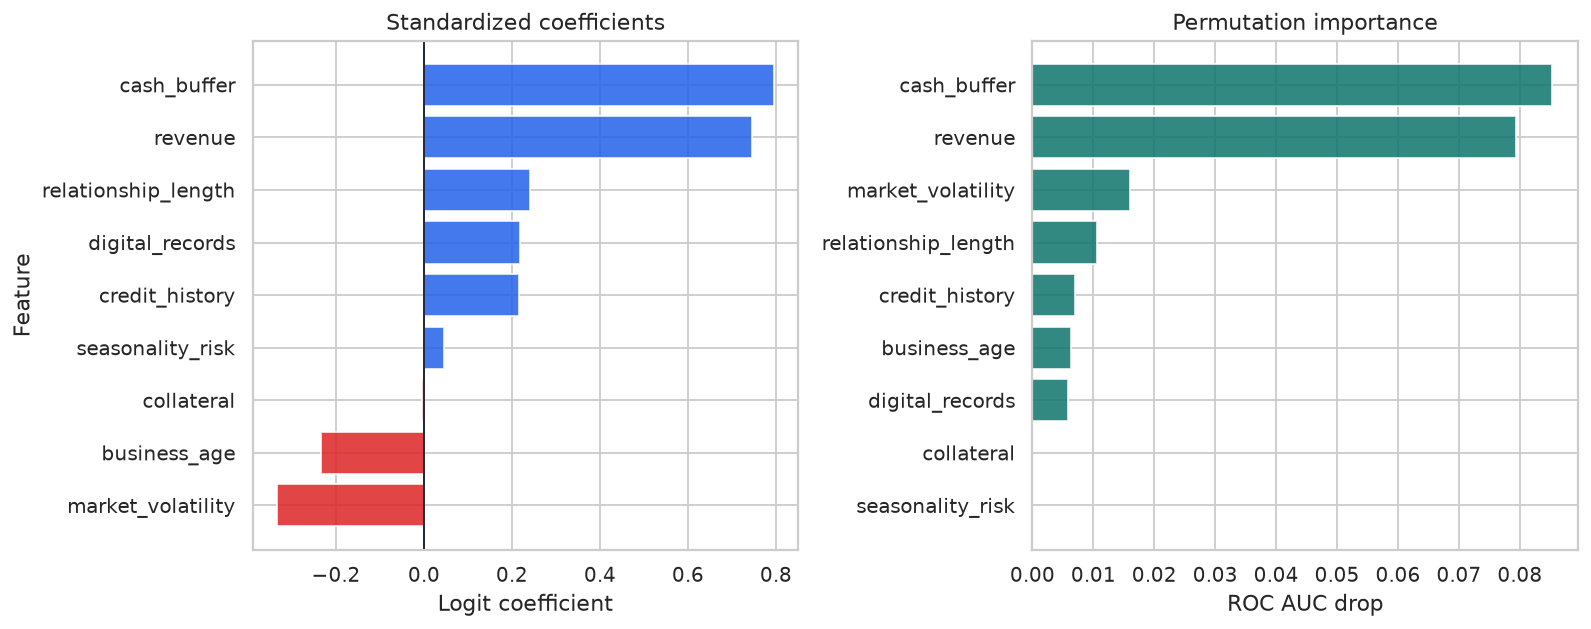

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))

coef_plot = coefs.sort_values()
axes[0].barh(coef_plot.index, coef_plot.values, color=np.where(coef_plot.values >= 0, '#2563eb', '#dc2626'), alpha=0.86)
axes[0].axvline(0, color='#111827', linewidth=1)
axes[0].set_title('Standardized coefficients')
axes[0].set_xlabel('Logit coefficient')
axes[0].set_ylabel('Feature')

perm_plot = perm_importance.sort_values()
axes[1].barh(perm_plot.index, perm_plot.values, color='#0f766e', alpha=0.86)
axes[1].set_title('Permutation importance')
axes[1].set_xlabel('ROC AUC drop')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The two views should be read together. Coefficients explain the direction of the linear score. Permutation importance explains how much evaluation performance depends on each feature. Neither should be translated into a causal claim without a causal design.

For Global Explanation, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


## 8. Explanation Stability Across Resamples

A deployment explanation should not depend on one lucky sample. We will refit the transparent model on bootstrap resamples of the training data and compare coefficient rankings to the original fitted model.

For each bootstrap model $b$, compute:

$$
\rho_b = \operatorname{corr}_{\text{Spearman}}(r_0, r_b),
$$

where $r_0$ is the original absolute-coefficient ranking and $r_b$ is the bootstrap ranking.

In [13]:
base_abs_rank = coefs.abs().rank(ascending=False, method='average')
base_top5 = set(coefs.abs().sort_values(ascending=False).head(5).index)

rng = np.random.default_rng(RANDOM_SEED)
stability_rows = []
for replicate in range(45):
    sample_idx = rng.integers(0, len(train_df), len(train_df))
    sample = train_df.iloc[sample_idx]
    boot_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    boot_model.fit(sample[model_features], sample['repays'])
    boot_coefs = pd.Series(boot_model.named_steps['logisticregression'].coef_[0], index=model_features)
    boot_rank = boot_coefs.abs().rank(ascending=False, method='average')
    rho = spearmanr(base_abs_rank.loc[model_features], boot_rank.loc[model_features]).statistic
    boot_top5 = set(boot_coefs.abs().sort_values(ascending=False).head(5).index)
    stability_rows.append({
        'replicate': replicate,
        'spearman_rank_correlation': rho,
        'top5_jaccard': len(base_top5 & boot_top5) / len(base_top5 | boot_top5),
    })

stability = pd.DataFrame(stability_rows)
stability_summary = stability[['spearman_rank_correlation', 'top5_jaccard']].agg(['mean', 'std', 'min', 'median']).T.reset_index()
stability_summary = stability_summary.rename(columns={'index': 'stability_metric'})
display_table(stability_summary, precision=3, max_width='760px')

,stability_metric,mean,std,min,median
0,spearman_rank_correlation,0.924,0.056,0.817,0.950
1,top5_jaccard,0.741,0.203,0.429,0.667


This result is an interpretation diagnostic. For Explanation Stability Across Resamples, look at whether the explanation is stable, plausible, and useful for stakeholder review. A dependable explanation should survive reasonable changes in settings.


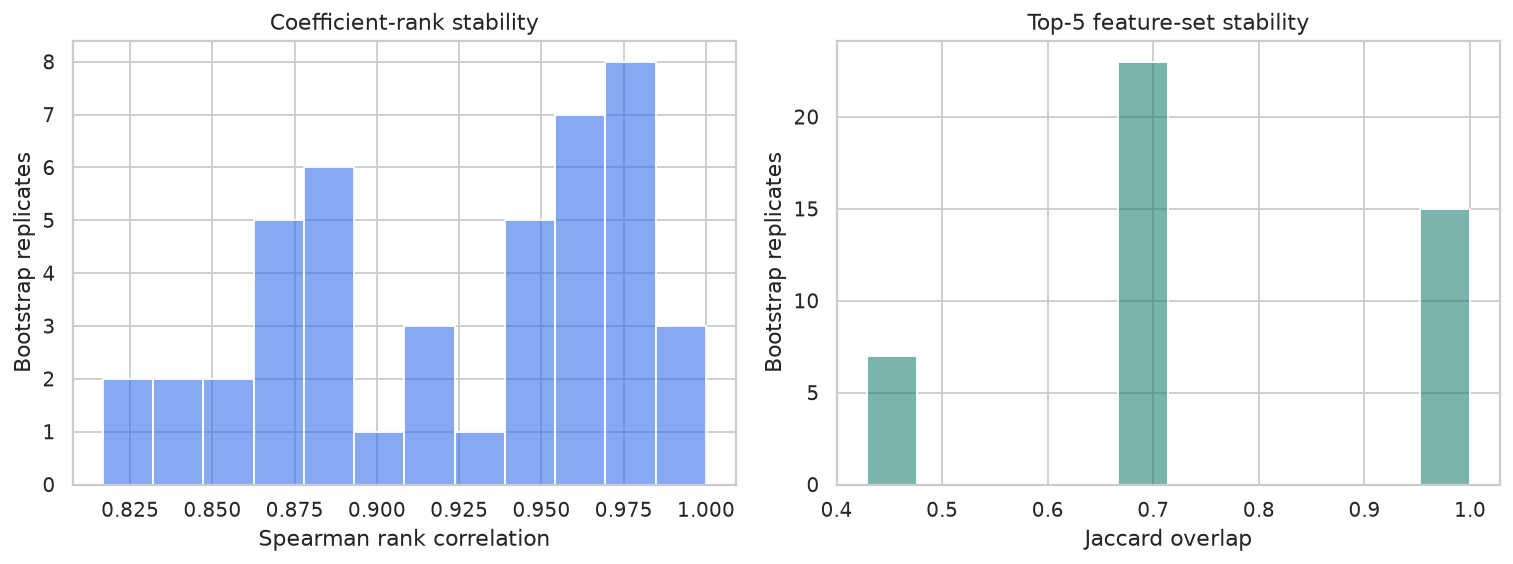

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))

sns.histplot(stability['spearman_rank_correlation'], bins=12, color='#2563eb', alpha=0.55, ax=axes[0])
axes[0].set_title('Coefficient-rank stability')
axes[0].set_xlabel('Spearman rank correlation')
axes[0].set_ylabel('Bootstrap replicates')

sns.histplot(stability['top5_jaccard'], bins=12, color='#0f766e', alpha=0.55, ax=axes[1])
axes[1].set_title('Top-5 feature-set stability')
axes[1].set_xlabel('Jaccard overlap')
axes[1].set_ylabel('Bootstrap replicates')

plt.tight_layout()
plt.show()

The global explanation is stable enough for reporting in this simulated case. If rank correlations or top-feature overlap were low, the deployment packet should label explanations as unstable or defer model use.

Read the plot as a diagnostic for the workflow. The main question is what visible pattern would change the analysis in Explanation Stability Across Resamples. If the groups separate clearly, a simple rule may be enough. Curvature and overlap point toward segmentation or further review.


## 9. Local Explanation and Analyst Case Card

We now build a local explanation for a denied, near-threshold application. This kind of case is operationally important because a small change in documentation, threshold, or manual-review policy could alter the decision.

The case card is meant to resemble a packet an analyst could send to a review lead. It should include the applicant's score, threshold position, main score drivers, feasible recourse, governance notes, and limits of the explanation. The point is to make the model decision inspectable without pretending the explanation is a legal or causal proof.

The experiment checks whether the full pipeline can support a single high-stakes review case from model output to stakeholder-facing language. That is where many XAI workflows break down: they generate a plot, but they do not produce an auditable explanation that a team can actually use.


In [15]:
# Section focus: 9. Local Explanation and Analyst Case Card.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

standardized_test = (test_df[model_features] - scaler.mean_) / scaler.scale_
contributions = standardized_test * pd.Series(logit_model.coef_[0], index=model_features)
logit_scores = logit_model.intercept_[0] + contributions.sum(axis=1)
logit_threshold = np.log(selected_threshold / (1 - selected_threshold))

test_df['logit_score'] = logit_scores
near_denied = test_df.loc[test_df['approved'] == 0].copy()
near_denied['threshold_gap'] = selected_threshold - near_denied['score']
focal_id = near_denied.sort_values('threshold_gap').index[2]
focal = test_df.loc[focal_id]
focal_contrib = contributions.loc[focal_id].sort_values()

case_summary = pd.DataFrame({
    'quantity': [
        'Decision',
        'Predicted repayment score',
        'Approval threshold',
        'Score gap to threshold',
        'Observed evaluation outcome',
        'Audit group',
    ],
    'value': [
        focal['decision'],
        focal['score'],
        selected_threshold,
        selected_threshold - focal['score'],
        'Repaid' if focal['repays'] == 1 else 'Did not repay',
        focal['access_group'],
    ],
})

display_table(case_summary, precision=3, max_width='700px')

,quantity,value
0,Decision,Deny or route to review
1,Predicted repayment score,0.699
2,Approval threshold,0.700
3,Score gap to threshold,0.001
4,Observed evaluation outcome,Repaid
5,Audit group,Established access group


Local Explanation and Analyst Case Card is a check on the model narrative. The explanation is useful when the reasons fit the data story, the decision context, and the limits of the method.


In [16]:
local_table = pd.DataFrame({
    'feature': focal_contrib.index,
    'local_logit_contribution': focal_contrib.values,
    'direction': np.where(focal_contrib.values >= 0, 'Raised score', 'Lowered score'),
})
local_table['abs_contribution'] = local_table['local_logit_contribution'].abs()
local_table = local_table.sort_values('abs_contribution', ascending=False)

display_table(local_table.drop(columns='abs_contribution'), precision=3, max_width='780px')

,feature,local_logit_contribution,direction
8,cash_buffer,0.311,Raised score
7,credit_history,0.250,Raised score
6,digital_records,0.162,Raised score
5,relationship_length,0.148,Raised score
4,market_volatility,0.147,Raised score
3,business_age,0.108,Raised score
0,revenue,-0.045,Lowered score
2,seasonality_risk,0.006,Raised score
1,collateral,-0.003,Lowered score


The metric result should be read as an operating tradeoff. In Local Explanation and Analyst Case Card, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The practical question is what the number would change in the workflow.


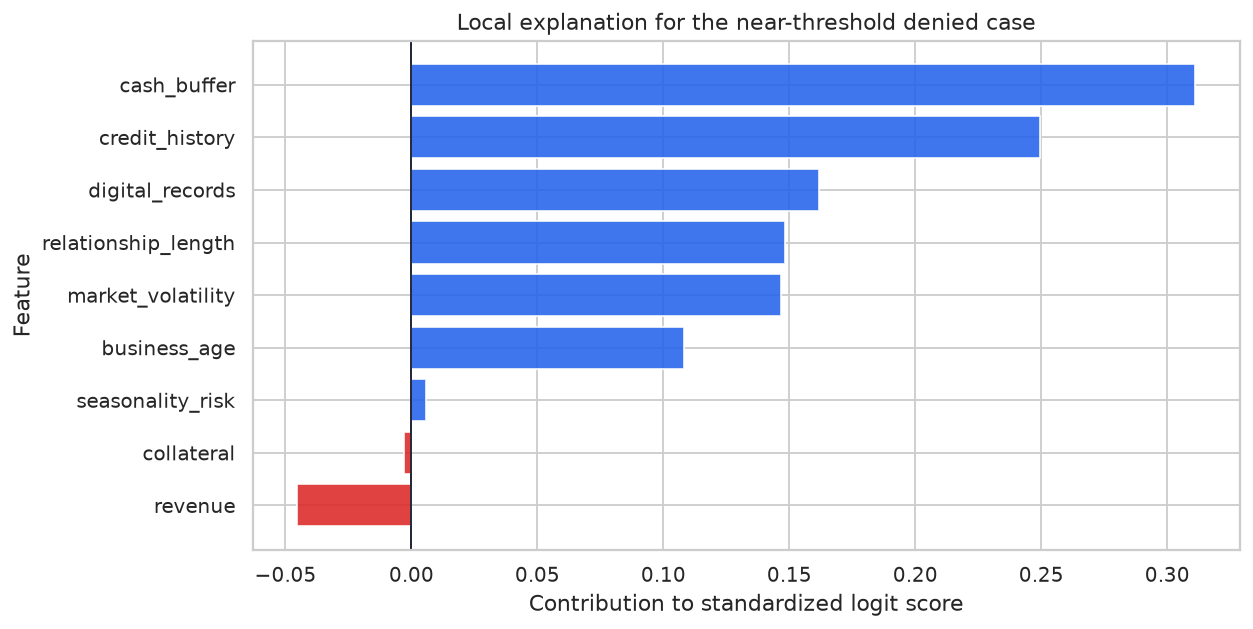

In [17]:
fig, ax = plt.subplots(figsize=(9.8, 5.0))
plot_local = focal_contrib.sort_values()
colors = ['#dc2626' if value < 0 else '#2563eb' for value in plot_local.values]
ax.barh(plot_local.index, plot_local.values, color=colors, alpha=0.88)
ax.axvline(0, color='#111827', linewidth=1)
ax.set_title('Local explanation for the near-threshold denied case')
ax.set_xlabel('Contribution to standardized logit score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Local Explanation and Analyst Case Card, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Weak explanations push the hard work back onto the reviewer.


In [18]:
# Section focus: 9. Local Explanation and Analyst Case Card.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def top_reasons(local_contrib, n=3, direction='negative', material_tolerance=0.01):
    """Carry out the top reasons step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
    
    Parameters
    ----------
    local_contrib : object
        The local contrib setting that controls the top reasons calculation in this notebook.
    n : object
        Number of observations or simulation units used by the calculation.
    direction : object
        The direction setting that controls the top reasons calculation in this notebook.
    material_tolerance : object
        The material tolerance setting that controls the top reasons calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the top reasons calculation and reused by later cells.
    """
    if direction == 'negative':
        selected = local_contrib[local_contrib < -material_tolerance].sort_values().head(n)
        fallback = 'No material score-lowering feature; case is below threshold because the total score is marginal.'
    else:
        selected = local_contrib[local_contrib > material_tolerance].sort_values(ascending=False).head(n)
        fallback = 'No material score-raising feature.'

    if selected.empty:
        return fallback
    return ', '.join(f'{feature} ({value:+.2f})' for feature, value in selected.items())

negative_reasons = top_reasons(focal_contrib, n=3, direction='negative')
positive_reasons = top_reasons(focal_contrib, n=2, direction='positive')

analyst_card = pd.DataFrame({
    'field': [
        'Case status',
        'Main score-lowering factors',
        'Main score-raising factors',
        'Decision guidance',
        'Communication caveat',
    ],
    'content': [
        f"Denied or route to review. Score is {focal['score']:.3f}; threshold is {selected_threshold:.3f}.",
        negative_reasons,
        positive_reasons,
        'Near-threshold case. Review updated financial documentation before final denial.',
        'These are model score factors, not causal findings about repayment behavior.',
    ],
})

display_table(analyst_card, precision=3, max_width='900px')


,field,content
0,Case status,Denied or route to review. Score is 0.699; threshold is 0.700.
1,Main score-lowering factors,revenue (-0.05)
2,Main score-raising factors,"cash_buffer (+0.31), credit_history (+0.25)"
3,Decision guidance,Near-threshold case. Review updated financial documentation before final denial.
4,Communication caveat,"These are model score factors, not causal findings about repayment behavior."


This local explanation is useful because it is tied to the decision threshold. It explains which features matter, why the case is below threshold and how an analyst should treat a near-threshold decision.

The explanation result should be compared with the decision story. In Local Explanation and Analyst Case Card, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A clear explanation lowers ambiguity for the stakeholder and makes review more focused.


## 10. Subgroup Audit and Recourse Burden

A deployment packet should not stop at average performance. It must check whether the selected policy behaves differently across groups.

In [19]:
# Section focus: 10. Subgroup Audit and Recourse Burden.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def subgroup_metrics(df):
    """Carry out the subgroup metrics step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for group_name, group_df in df.groupby('access_group'):
        y = group_df['repays'].to_numpy()
        yhat = group_df['approved'].to_numpy()
        rows.append({
            'access_group': group_name,
            'n': len(group_df),
            'repayment_rate': y.mean(),
            'mean_score': group_df['score'].mean(),
            'approval_rate': yhat.mean(),
            'true_positive_rate': safe_divide(((yhat == 1) & (y == 1)).sum(), (y == 1).sum()),
            'false_positive_rate': safe_divide(((yhat == 1) & (y == 0)).sum(), (y == 0).sum()),
            'precision_among_approved': safe_divide(((yhat == 1) & (y == 1)).sum(), (yhat == 1).sum()),
        })
    return pd.DataFrame(rows)

subgroup_table = subgroup_metrics(test_df)
display_table(subgroup_table, precision=3, max_width='940px')

,access_group,n,repayment_rate,mean_score,approval_rate,true_positive_rate,false_positive_rate,precision_among_approved
0,Established access group,1938,0.501,0.506,0.314,0.546,0.082,0.870
1,Underserved access group,1037,0.378,0.359,0.164,0.352,0.050,0.812


Use the explanation as a stress test of the model narrative. In Subgroup Audit and Recourse Burden, the displayed reasons should make sense with the data-generating story and the operating decision. The analyst should treat explanation disagreement as evidence about reliability.


In [20]:
actionable_features = ['revenue', 'cash_buffer', 'credit_history', 'digital_records', 'relationship_length']
positive_actionable = pd.Series(logit_model.coef_[0], index=model_features)[actionable_features].clip(lower=0)
actionable_norm = np.linalg.norm(positive_actionable.values)

test_df['recourse_burden'] = np.maximum(0, logit_threshold - test_df['logit_score']) / actionable_norm
qualified_denied = test_df.loc[(test_df['approved'] == 0) & (test_df['repays'] == 1)].copy()

burden_summary = (
    qualified_denied
    .groupby('access_group')
    .agg(
        qualified_denied_cases=('recourse_burden', 'size'),
        mean_burden=('recourse_burden', 'mean'),
        median_burden=('recourse_burden', 'median'),
        p75_burden=('recourse_burden', lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

display_table(burden_summary, precision=3, max_width='780px')

,access_group,qualified_denied_cases,mean_burden,median_burden,p75_burden
0,Established access group,441,0.923,0.749,1.312
1,Underserved access group,254,1.153,1.067,1.641


Use the explanation as a stress test of the model narrative. In Subgroup Audit and Recourse Burden, the displayed reasons should make sense with the data-generating story and the operating decision. The explanation is still provisional when different methods tell different local stories.


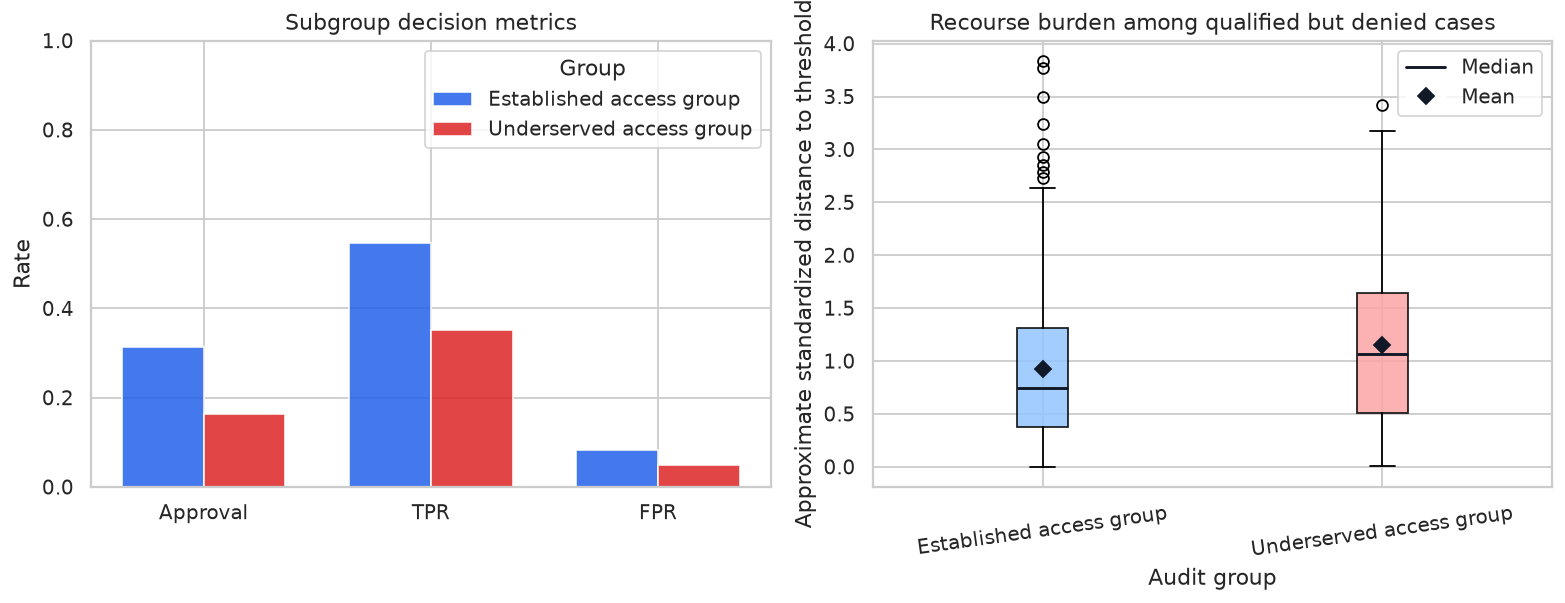

In [21]:
# Section focus: 10. Subgroup Audit and Recourse Burden.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8))

metric_plot = subgroup_table.set_index('access_group')[['approval_rate', 'true_positive_rate', 'false_positive_rate']]
x = np.arange(metric_plot.shape[1])
width = 0.36
for offset, group_name, color in [
    (-width / 2, 'Established access group', '#2563eb'),
    (width / 2, 'Underserved access group', '#dc2626'),
]:
    axes[0].bar(x + offset, metric_plot.loc[group_name], width=width, label=group_name, color=color, alpha=0.86)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Approval', 'TPR', 'FPR'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Subgroup decision metrics')
axes[0].set_ylabel('Rate')
axes[0].legend(title='Group')

group_order = ['Established access group', 'Underserved access group']
box_data = [qualified_denied.loc[qualified_denied['access_group'] == group, 'recourse_burden'] for group in group_order]
box = axes[1].boxplot(box_data, patch_artist=True, showmeans=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(group_order, rotation=8)
for patch, color in zip(box['boxes'], ['#93c5fd', '#fca5a5']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for median in box['medians']:
    median.set_color('#111827')
    median.set_linewidth(1.6)
for mean in box['means']:
    mean.set_marker('D')
    mean.set_markerfacecolor('#111827')
    mean.set_markeredgecolor('#111827')
axes[1].legend(
    handles=[
        Line2D([0], [0], color='#111827', linewidth=1.6, label='Median'),
        Line2D([0], [0], marker='D', color='white', markerfacecolor='#111827', markeredgecolor='#111827', markersize=6, label='Mean'),
    ],
    loc='upper right',
    frameon=True,
)
axes[1].set_title('Recourse burden among qualified but denied cases')
axes[1].set_ylabel('Approximate standardized distance to threshold')
axes[1].set_xlabel('Audit group')

plt.tight_layout()
plt.show()


The subgroup audit triggers governance review. The selected model can still be useful, but a deployment decision should include monitoring, review paths for near-threshold cases, and careful recourse language.

Subgroup Audit and Recourse Burden is useful only if the explanation remains credible under reasonable modeling choices.


## 11. Pipeline Flowchart

The final pipeline connects modeling, explanation, governance, and communication.

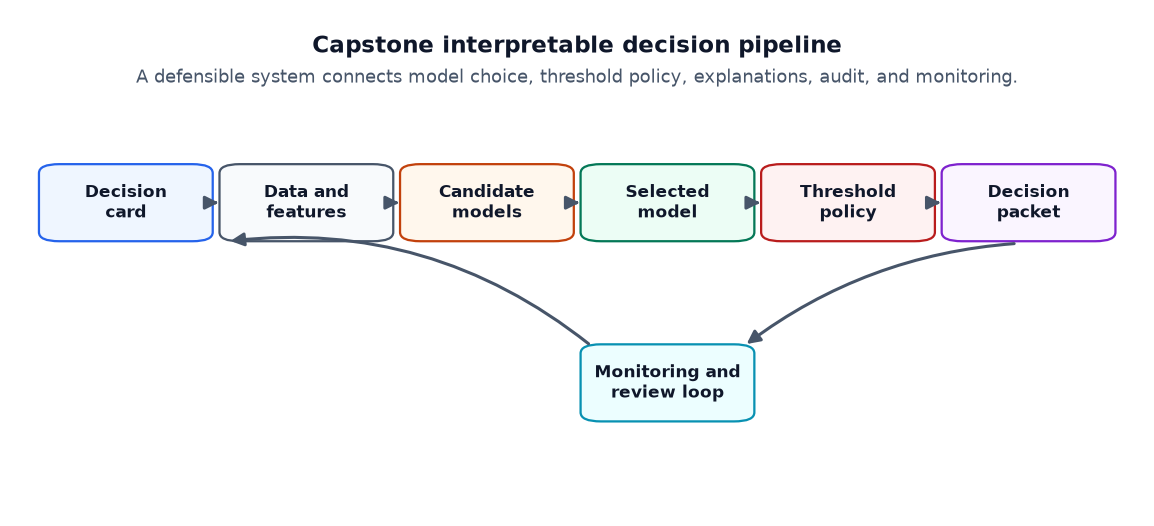

In [22]:
# Section focus: 11. Pipeline Flowchart.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def draw_capstone_pipeline():
    """Carry out the draw capstone pipeline step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    fig, ax = plt.subplots(figsize=(11.2, 5.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    boxes = [
        ('Decision\ncard', 0.10, 0.62, '#eff6ff', '#2563eb'),
        ('Data and\nfeatures', 0.26, 0.62, '#f8fafc', '#475569'),
        ('Candidate\nmodels', 0.42, 0.62, '#fff7ed', '#c2410c'),
        ('Selected\nmodel', 0.58, 0.62, '#ecfdf5', '#047857'),
        ('Threshold\npolicy', 0.74, 0.62, '#fef2f2', '#b91c1c'),
        ('Decision\npacket', 0.90, 0.62, '#faf5ff', '#7e22ce'),
        ('Monitoring and\nreview loop', 0.58, 0.26, '#ecfeff', '#0891b2'),
    ]

    def add_box(label, x, y, face, edge):
        """Carry out the add box step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
        
        Parameters
        ----------
        label : object
            Human-readable label used to name a model, scenario, metric, or plotted series.
        x : object
            Numeric score, scalar, or array passed through the transformation in this helper.
        y : object
            Observed target values used for fitting or evaluation.
        face : object
            Face color used to encode a node or region in a graph or plot.
        edge : object
            Graph edge being drawn, classified, or checked for consistency.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        patch = FancyBboxPatch(
            (x - 0.065, y - 0.065), 0.13, 0.13,
            boxstyle='round,pad=0.012,rounding_size=0.018',
            facecolor=face, edgecolor=edge, linewidth=1.25,
        )
        ax.add_patch(patch)
        ax.text(x, y, label, ha='center', va='center', fontsize=9.2, weight='bold', color='#0f172a')

    def arrow(start, end, rad=0.0):
        """Carry out the arrow step used in the 17. Capstone: An Interpretable Decision Pipeline workflow.
        
        Parameters
        ----------
        start : object
            Starting index, time, or location for the simulated event window.
        end : object
            Ending index, time, or location for the simulated event window.
        rad : object
            Curvature setting used to route a graph edge around other visual elements.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        ax.add_patch(FancyArrowPatch(
            start, end,
            connectionstyle=f'arc3,rad={rad}',
            arrowstyle='-|>', mutation_scale=15,
            linewidth=1.7, color='#475569', shrinkA=8, shrinkB=8,
        ))

    for label, x, y, face, edge in boxes:
        add_box(label, x, y, face, edge)

    for x0, x1 in [(0.165, 0.195), (0.325, 0.355), (0.485, 0.515), (0.645, 0.675), (0.805, 0.835)]:
        arrow((x0, 0.62), (x1, 0.62))
    arrow((0.90, 0.54), (0.64, 0.32), rad=0.16)
    arrow((0.52, 0.32), (0.18, 0.54), rad=0.22)

    ax.text(0.50, 0.92, 'Capstone interpretable decision pipeline', ha='center', fontsize=13, weight='bold', color='#0f172a')
    ax.text(0.50, 0.86, 'A defensible system connects model choice, threshold policy, explanations, audit, and monitoring.', ha='center', fontsize=10, color='#475569')
    return fig, ax

draw_capstone_pipeline();
plt.show()

This diagram is the central message of the course. Interpretable ML is not a single plot. It is a decision pipeline with evidence, policy, explanation, review, and monitoring.

In Pipeline Flowchart, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. The report should make this sensitivity visible to the reader.


## 12. Deployment Review Record

The final artifact is a deployment record. This is a compact version of what would become a model card, audit packet, or deployment memo.

In [23]:
# Section focus: 12. Deployment Review Record.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_hash = short_hash(model_features)
data_signature = short_hash(
    applications[['underserved_access_group', 'revenue', 'cash_buffer', 'credit_history', 'repays']]
    .head(250)
    .round(6)
    .to_dict(orient='records')
)
metric_signature = short_hash(
    pd.concat([
        selected_metrics.assign(section='selected_metrics'),
        subgroup_table.assign(section='subgroup_metrics'),
    ], ignore_index=True)
    .round(6)
    .to_dict(orient='records')
)

review_record = pd.DataFrame({
    'review_item': [
        'Decision supported',
        'Selected model',
        'Rejected challenger',
        'Feature set hash',
        'Data snapshot signature',
        'Metric snapshot signature',
        'Selected threshold',
        'Explanation method',
        'Stability result',
        'Fairness status',
        'Deployment recommendation',
        'Monitoring requirements',
    ],
    'record': [
        'Working-capital approval, denial, or manual review.',
        'Standardized logistic regression.',
        'Random forest: not selected because it did not improve evaluation performance and is less transparent.',
        feature_hash,
        data_signature,
        metric_signature,
        f'{selected_threshold:.3f}',
        'Standardized coefficients, permutation importance, local logit contributions.',
        f"Median coefficient-rank Spearman = {stability['spearman_rank_correlation'].median():.3f}; median top-5 Jaccard = {stability['top5_jaccard'].median():.3f}.",
        'Subgroup gaps and recourse burden require governance review before full automation.',
        'Conditional deployment: use as decision support with manual review for near-threshold and escalated cases.',
        'Monitor calibration, approval rate, subgroup TPR/FPR, denial reasons, override rates, and drift.',
    ],
})

display_table(review_record, precision=3, max_width='980px')

,review_item,record
0,Decision supported,"Working-capital approval, denial, or manual review."
1,Selected model,Standardized logistic regression.
2,Rejected challenger,Random forest: not selected because it did not improve evaluation performance and is less transparent.
3,Feature set hash,4c9213b46e97
4,Data snapshot signature,d39b7f85c34c
5,Metric snapshot signature,2a6348bcd390
6,Selected threshold,0.700
7,Explanation method,"Standardized coefficients, permutation importance, local logit contributions."
8,Stability result,Median coefficient-rank Spearman = 0.950; median top-5 Jaccard = 0.667.
9,Fairness status,Subgroup gaps and recourse burden require governance review before full automation.


Read Deployment Review Record as a stress test for the explanation. Stable reasons strengthen the story; shifting local reasons should stay in the caveats.


## 13. Executive Summary

A concise stakeholder summary should tell the truth without drowning the decision-maker in implementation detail.

In [24]:
executive_summary = pd.DataFrame({
    'message_type': ['Decision', 'Evidence', 'Risk', 'Recommendation'],
    'summary': [
        f"Select the transparent logistic regression model for the working-capital decision pipeline.",
        f"Evaluation ROC AUC is {selected_metrics.loc[selected_metrics['metric'] == 'ROC AUC', 'value'].iloc[0]:.3f}; selected threshold is {selected_threshold:.3f}; approval rate is {test_df['approved'].mean():.3f}.",
        "Subgroup approval and true-positive-rate gaps require governance review; explanations must not be communicated as causal claims.",
        "Deploy conditionally as analyst decision support, with manual review for near-threshold cases and monitoring of calibration, subgroup metrics, explanation stability, and recourse burden.",
    ],
})

display_table(executive_summary, precision=3, max_width='920px')

,message_type,summary
0,Decision,Select the transparent logistic regression model for the working-capital decision pipeline.
1,Evidence,Evaluation ROC AUC is 0.836; selected threshold is 0.700; approval rate is 0.262.
2,Risk,Subgroup approval and true-positive-rate gaps require governance review; explanations must not be communicated as causal claims.
3,Recommendation,"Deploy conditionally as analyst decision support, with manual review for near-threshold cases and monitoring of calibration, subgroup metrics, explanation stability, and recourse burden."


For Executive Summary, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


## 14. What This Capstone Demonstrates

This notebook used nearly every concept in the course:

| Course idea | Where it appeared in the capstone |
|---|---|
| Transparent baselines | Logistic regression selected as a strong first-class model |
| Black-box comparison | Random forest used as a challenger model |
| Global explanations | Coefficients and permutation importance |
| Local explanations | Near-threshold focal-case contributions |
| Threshold-aware decisions | Utility-based threshold selection |
| Explanation stability | Bootstrap coefficient-rank stability |
| Fairness and governance | Subgroup metrics and recourse burden |
| Communication | Analyst card, executive summary, deployment record |
| Causal caution | Explanation language avoids unsupported causal claims |
| Monitoring | Final review record includes post-deployment checks |

## 15. Key Takeaways

- Interpretable ML is a workflow, not a single explanation method.
- Transparent models should be treated as serious baselines, especially when they are competitive.
- Threshold choice is a policy decision informed by utility, risk, fairness, and capacity.
- Global and local explanations answer different questions and should both be checked.
- Explanation stability matters before explanations are used in stakeholder communication.
- Fairness and recourse audits are part of interpretability governance.
- A deployment-ready model needs a decision record alongside a notebook with plots.

## References

Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *arXiv*. [https://doi.org/10.48550/arxiv.1610.02413](https://doi.org/10.48550/arxiv.1610.02413)

Janzing, D., Minorics, L., & Bloebaum, P. (2019). Feature relevance quantification in explainable AI: A causal problem. *arXiv*. [https://doi.org/10.48550/arxiv.1910.13413](https://doi.org/10.48550/arxiv.1910.13413)

Lipton, Z. C. (2018). The mythos of model interpretability. *Communications of the ACM, 61*(10), 36-43. [https://doi.org/10.1145/3233231](https://doi.org/10.1145/3233231)

Miller, T. (2019). Explanation in artificial intelligence: Insights from the social sciences. *Artificial Intelligence, 267*, 1-38. [https://doi.org/10.1016/j.artint.2018.07.007](https://doi.org/10.1016/j.artint.2018.07.007)

Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2019). Model cards for model reporting. *Proceedings of the Conference on Fairness, Accountability, and Transparency*, 220-229. [https://doi.org/10.1145/3287560.3287596](https://doi.org/10.1145/3287560.3287596)

Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). Why should I trust you? Explaining the predictions of any classifier. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1135-1144. [https://doi.org/10.1145/2939672.2939778](https://doi.org/10.1145/2939672.2939778)
